In [ ]:
!pip install windpowerlib

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from windpowerlib import ModelChain, WindTurbine
from windpowerlib import data as wt

In [ ]:
weather_data= pd.read_csv('weather_montreal.csv',  index_col = 0,header = [0,1]) # To consider datetime as index and the first two rows as headers
weather_data.index = pd.to_datetime(weather_data.index, utc=True) # To convertweather_data the datetime format

**Wind Turbine Selection**

In [ ]:
turbine_lib = wt.get_turbine_types(print_out = False) # Because the data is not that good looking
turbine_lib # Printing this would give a good data

In [15]:
selected_turbine = {'turbine_type':'E48/800', 'hub_height': 60}
wind_turbine = WindTurbine(**selected_turbine)

In [24]:
Turbine_Sub_Models = {
    'wind_speed_model' : 'hellman',                           #'hellman','logerithmic'(default), 'interpolation-exterpolation'
    'density_model' : 'ideal_gas',                            #'Barometric'(default) ,'ideal_gas', 'interpolation-exterpolation'
    'temperature_model' : 'linear_gradient',                  #'linear_gradient', 'interpolation-exterpolation'
    'power_output_model' : 'power_coefficient_curve',         #'power_curve' (default), 'power_coefficient_curve'
    'density_correction' : True,                              #True, False (default)
    'obstacle_height': 0,                                     # Imagine no obstrucle, if you have any put the height of it (default is 0)
    'hellman_exp' : 0.25                                      # refer the lecture notes for friction values for various terrains (default is 9)
    }


In [25]:
model = ModelChain(wind_turbine, **Turbine_Sub_Models).run_model(weather_data)

In [ ]:
Turbine_Power_Output = (model.power_output) / 10**3 # To covert from [W] to [kW]
Turbine_Power_Output

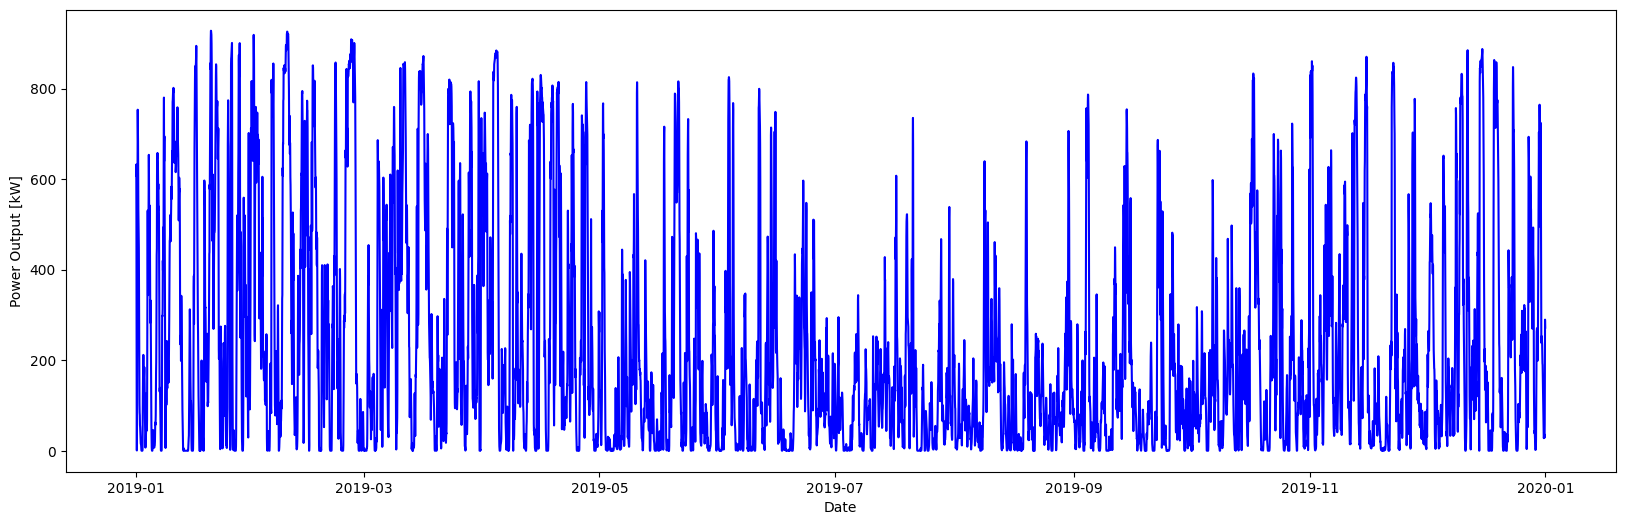

In [36]:
plt.figure(figsize=(20,6))
plt.plot(Turbine_Power_Output, color = 'blue')
plt.xlabel("Date")
plt.ylabel("Power Output [kW]")
plt.show()